In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import os
import json
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ==========================
# DATA LOADING AND PREPROCESSING
# ==========================
def load_and_preprocess_data(file_path):
    """
    Load and preprocess the dataset
    """
    print("📁 LOADING DATASET...")
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace('\n', ' ')
    df.columns = df.columns.str.replace('  ', ' ')

    print(f"✅ Dataset loaded: {df.shape}")
    return df

def prepare_features(df, target_col='Asylum Seekers'):
    """
    Prepare features for XGBoost model - FIXED to avoid leakage
    """
    df_processed = df.copy()

    print("\n🔧 PREPARING FEATURES FOR XGBOOST...")

    # 1. Handle missing values
    print("   Handling missing values...")
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if col != target_col and col != 'Country' and col != 'Year':
            # Fill with median by country
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            # If still missing, fill with overall median
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # 2. Encode categorical variables
    print("   Encoding categorical variables...")
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

    # 3. Create time-based features
    print("   Creating time-based features...")
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # 4. Create lag features for key variables
    print("   Creating lag features...")
    key_vars = [
        'D_Expenditure_GDP',
        'Asylum Seekers',
        'GDP_Current_USDollars',
        'Population',
        'Refugees'
    ]

    existing_vars = [var for var in key_vars if var in df_processed.columns]

    for var in existing_vars:
        for lag in [1, 2, 3]:
            df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)

    # 5. Create rolling statistics (FIXED to avoid leakage)
    print("   Creating rolling statistics...")
    for var in ['D_Expenditure_GDP']:  # Only for defense, NOT for target!
        if var in df_processed.columns:
            df_processed[f'{var}_Rolling_Mean_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )

    # 6. Create interaction features with defense expenditure
    print("   Creating interaction features...")
    if 'D_Expenditure_GDP' in df_processed.columns:
        if 'GDP_Current_USDollars' in df_processed.columns:
            df_processed['Defense_GDP_Interaction'] = df_processed['D_Expenditure_GDP'] * np.log1p(df_processed['GDP_Current_USDollars'])
        if 'Conflict_Intensity' in df_processed.columns:
            df_processed['Defense_Conflict_Interaction'] = df_processed['D_Expenditure_GDP'] * df_processed['Conflict_Intensity']
        df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP'] ** 2

    # 7. Fill remaining NaN values
    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill').fillna(0)

    print(f"✅ Final dataset shape: {df_processed.shape}")
    return df_processed, le_country

# ==========================
# XGBOOST ONLY MODEL WITH H5 SAVING
# ==========================
class XGBoostOnlyModel:
    """
    ONLY XGBoost model for asylum prediction with .h5 saving
    """
    def __init__(self):
        self.model = None
        self.booster = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None
        self.r2_score = None
        self.mae = None

    def get_features(self, df, feature_set='Full_Model'):
        """
        Get features for XGBoost model
        """
        base_features = [
            'Year_Scaled',
            'Country_Encoded',
            'D_Expenditure_GDP',
        ]

        defense_features = [
            'D_Expenditure_GDP_Lag_1',
            'D_Expenditure_GDP_Lag_2',
            'D_Expenditure_GDP_Rolling_Mean_3',
            'Defense_Squared',
        ]

        economic_features = [
            'GDP_Current_USDollars',
            'GDP_Growth_Annual',
            'Inflation_Annual',
            'Unemployment_Total_of_TLF',
        ]

        migration_features = [
            'Refugees',
            'Refugees_Lag_1',
            'Asylum Seekers_Lag_1',
            'Asylum Seekers_Lag_2',
        ]

        # Add interaction features if they exist
        interaction_features = []
        if 'Defense_GDP_Interaction' in df.columns:
            interaction_features.append('Defense_GDP_Interaction')
        if 'Defense_Conflict_Interaction' in df.columns:
            interaction_features.append('Defense_Conflict_Interaction')

        # Choose feature set
        if feature_set == 'Defense_Only':
            all_features = base_features + defense_features + interaction_features
        elif feature_set == 'Defense_Economic':
            all_features = base_features + defense_features + economic_features + interaction_features
        elif feature_set == 'Defense_Migration':
            all_features = base_features + defense_features + migration_features + interaction_features
        else:  # Full_Model
            all_features = (base_features + defense_features + economic_features +
                          migration_features + interaction_features)

        # Remove duplicates and filter to existing columns
        all_features = list(set(all_features))
        available_features = [f for f in all_features if f in df.columns]

        print(f"\n📋 XGBOOST FEATURES ({len(available_features)} total)")
        return available_features

    def train(self, df, feature_set='Full_Model', target_col='Asylum Seekers',
              test_years=[2020, 2021, 2022, 2023, 2024]):
        """
        Train XGBoost model
        """
        print("\n" + "="*60)
        print(f"🚀 TRAINING XGBOOST - {feature_set}")
        print("="*60)

        # Get features
        self.feature_names = self.get_features(df, feature_set)

        # Prepare data
        X = df[self.feature_names]
        y = df[target_col]

        # Split by time
        train_mask = ~df['Year'].isin(test_years)
        test_mask = df['Year'].isin(test_years)

        X_train = X[train_mask]
        X_test = X[test_mask]
        y_train = y[train_mask]
        y_test = y[test_mask]

        print(f"\n📊 Data Split: {len(X_train)} training, {len(X_test)} testing")

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Train XGBoost model
        print("\n🤖 Training XGBoost...")
        self.model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1
        )

        self.model.fit(X_train_scaled, y_train)

        # Create native booster for saving
        self.booster = self.model.get_booster()

        print("✅ Training complete!")

        # Evaluate
        self.evaluate(X_test_scaled, y_test)

        return self.model

    def evaluate(self, X_test, y_test):
        """Evaluate model performance"""
        y_pred = self.model.predict(X_test)

        # Overall metrics
        self.r2_score = r2_score(y_test, y_pred)
        self.mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"\n📈 XGBoost Performance:")
        print(f"  R² Score:  {self.r2_score:.4f} ({self.r2_score*100:.1f}% accuracy)")
        print(f"  MAE:       {self.mae:,.2f} asylum seekers")
        print(f"  RMSE:      {rmse:,.2f} asylum seekers")

    # ==========================
    # H5 SAVING FUNCTION - XGBOOST ONLY
    # ==========================
    def save_to_h5(self, filename='xgboost_asylum_model.h5'):
        """
        Save XGBoost model to .h5 format
        """
        print("\n" + "="*60)
        print("💾 SAVING XGBOOST MODEL TO .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'w') as f:

            # 1. Save metadata
            f.attrs['model_type'] = 'XGBoost Asylum Predictor'
            f.attrs['r2_score'] = self.r2_score if self.r2_score else 0.0
            f.attrs['mae'] = self.mae if self.mae else 0.0
            f.attrs['n_features'] = len(self.feature_names) if self.feature_names else 0
            f.attrs['created_date'] = str(datetime.now())

            # 2. Save XGBoost model (as bytes)
            model_bytes = self.booster.save_raw()
            f.create_dataset('model_bytes', data=np.frombuffer(model_bytes, dtype='uint8'))

            # 3. Save feature names
            if self.feature_names:
                dt = h5py.string_dtype(encoding='utf-8')
                f.create_dataset('feature_names',
                               data=np.array(self.feature_names, dtype=object).astype('S'),
                               dtype=dt)

            # 4. Save scaler parameters
            if self.scaler:
                f.create_dataset('scaler_mean', data=self.scaler.mean_)
                f.create_dataset('scaler_scale', data=self.scaler.scale_)
                if hasattr(self.scaler, 'var_'):
                    f.create_dataset('scaler_var', data=self.scaler.var_)

            # 5. Save country mapping
            if self.le_country:
                country_group = f.create_group('country_mapping')
                dt = h5py.string_dtype(encoding='utf-8')
                country_data = np.array(list(self.le_country.classes_), dtype=object).astype('S')
                country_group.create_dataset('countries', data=country_data, dtype=dt)
                country_group.create_dataset('country_codes', data=self.le_country.transform(self.le_country.classes_))

            # 6. Save model configuration
            config_group = f.create_group('config')
            config = self.model.get_xgb_params()
            for key, value in config.items():
                if isinstance(value, (int, float, str, bool)):
                    config_group.attrs[key] = str(value)

        file_size = os.path.getsize(filename) / 1024
        print(f"✅ XGBoost model saved to: {filename}")
        print(f"   File size: {file_size:.2f} KB")
        print(f"   R² Score: {self.r2_score:.4f}")

        return filename

    # ==========================
    # LOADING FUNCTION
    # ==========================
    def load_from_h5(self, filename):
        """
        Load XGBoost model from .h5 format
        """
        print("\n" + "="*60)
        print("📂 LOADING XGBOOST MODEL FROM .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'r') as f:

            # Load metadata
            print(f"\n📊 Model Info:")
            print(f"   Type: {f.attrs['model_type']}")
            print(f"   R² Score: {f.attrs['r2_score']:.4f}")
            print(f"   MAE: {f.attrs['mae']:,.2f}")
            print(f"   Features: {f.attrs['n_features']}")
            print(f"   Created: {f.attrs['created_date']}")

            # Load XGBoost model
            model_bytes = f['model_bytes'][:].tobytes()
            self.booster = xgb.Booster()
            self.booster.load_raw(model_bytes)

            # Recreate XGBoost regressor
            self.model = XGBRegressor()
            self.model._Booster = self.booster

            # Load feature names
            if 'feature_names' in f:
                feature_names = f['feature_names'][:]
                self.feature_names = [name.decode('utf-8') if isinstance(name, bytes) else name
                                     for name in feature_names]

            # Load scaler
            if 'scaler_mean' in f and 'scaler_scale' in f:
                self.scaler = StandardScaler()
                self.scaler.mean_ = f['scaler_mean'][:]
                self.scaler.scale_ = f['scaler_scale'][:]
                if 'scaler_var' in f:
                    self.scaler.var_ = f['scaler_var'][:]

        print(f"✅ XGBoost model loaded from: {filename}")
        return self

    def predict(self, X):
        """
        Make predictions using the loaded model
        """
        if self.model is None:
            print("❌ No model loaded!")
            return None

        # Scale features
        X_scaled = self.scaler.transform(X)

        # Predict
        predictions = self.model.predict(X_scaled)

        return predictions

# ==========================
# MAIN EXECUTION
# ==========================
def main():
    print("="*60)
    print("🎯 XGBOOST ONLY - ASYLUM MODEL WITH H5 SAVING")
    print("="*60)

    # Load data
    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'
    df = load_and_preprocess_data(file_path)

    # Prepare features
    df_processed, le_country = prepare_features(df)

    # Create XGBoost model
    model = XGBoostOnlyModel()
    model.le_country = le_country

    # Train on Full Model (or change to 'Defense_Only' if you prefer)
    model.train(df_processed, feature_set='Full_Model', target_col='Asylum Seekers')

    # Save to H5
    h5_file = model.save_to_h5('xgboost_asylum_model.h5')

    print(f"\n{'='*60}")
    print("✅ ANALYSIS COMPLETE!")
    print('='*60)

    # Show file location
    print(f"\n📍 File saved at: {os.path.abspath('xgboost_asylum_model.h5')}")
    print(f"   File size: {os.path.getsize('xgboost_asylum_model.h5') / 1024:.2f} KB")

    # Optional: Download in Colab
    try:
        from google.colab import files
        print("\n📥 Downloading file to your computer...")
        files.download('xgboost_asylum_model.h5')
    except:
        pass

    print("\n📌 TO USE THE MODEL LATER:")
    print("   from xgboost_model import XGBoostOnlyModel")
    print("   model = XGBoostOnlyModel()")
    print("   model.load_from_h5('xgboost_asylum_model.h5')")
    print("   predictions = model.predict(X_new)")

    return model, h5_file

# Run the model
if __name__ == "__main__":
    model, h5_file = main()

🎯 XGBOOST ONLY - ASYLUM MODEL WITH H5 SAVING
📁 LOADING DATASET...
✅ Dataset loaded: (155, 27)

🔧 PREPARING FEATURES FOR XGBOOST...
   Handling missing values...
   Encoding categorical variables...
   Creating time-based features...
   Creating lag features...
   Creating rolling statistics...
   Creating interaction features...
✅ Final dataset shape: (155, 48)

🚀 TRAINING XGBOOST - Full_Model

📋 XGBOOST FEATURES (17 total)

📊 Data Split: 130 training, 25 testing

🤖 Training XGBoost...
✅ Training complete!

📈 XGBoost Performance:
  R² Score:  0.7349 (73.5% accuracy)
  MAE:       16,055.72 asylum seekers
  RMSE:      29,538.82 asylum seekers

💾 SAVING XGBOOST MODEL TO .h5 FORMAT
✅ XGBoost model saved to: xgboost_asylum_model.h5
   File size: 397.80 KB
   R² Score: 0.7349

✅ ANALYSIS COMPLETE!

📍 File saved at: /content/xgboost_asylum_model.h5
   File size: 397.80 KB

📥 Downloading file to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📌 TO USE THE MODEL LATER:
   from xgboost_model import XGBoostOnlyModel
   model = XGBoostOnlyModel()
   model.load_from_h5('xgboost_asylum_model.h5')
   predictions = model.predict(X_new)


# **TESTING CLUSTERS**


🎯 XGBOOST FULL MODEL FOR ASYLUM SEEKER PREDICTION
📁 LOADING DATASET...
✅ Dataset loaded: (155, 27)

🔧 PREPARING FEATURES FOR XGBOOST...
   Handling missing values...
   Encoding categorical variables...
   Country mapping: {'CHN': np.int64(0), 'FRA': np.int64(1), 'GBR': np.int64(2), 'RUS': np.int64(3), 'USA': np.int64(4)}
   Creating time-based features...
   Creating lag features...
   Creating rolling statistics...
   Creating interaction features...
✅ Final dataset shape: (155, 49)
✅ Total features: 49

🚀 TRAINING XGBOOST FULL MODEL

📋 FULL MODEL FEATURES (20 total):
  1. Asylum Seekers_Lag_1
  2. Asylum Seekers_Lag_2
  3. Asylum Seekers_Rolling_Mean_3
  4. Country_Encoded
  5. D_Expenditure_GDP
  6. D_Expenditure_GDP_Lag_1
  7. D_Expenditure_GDP_Lag_2
  8. D_Expenditure_GDP_Rolling_Mean_3
  9. Defense_Conflict_Interaction
  10. Defense_GDP_Interaction
  11. Defense_Squared
  12. Environmental impact (CO2e/capita)
  13. GDP_Current_USDollars
  14. GDP_Growth_Annual
  15. Inflation_A

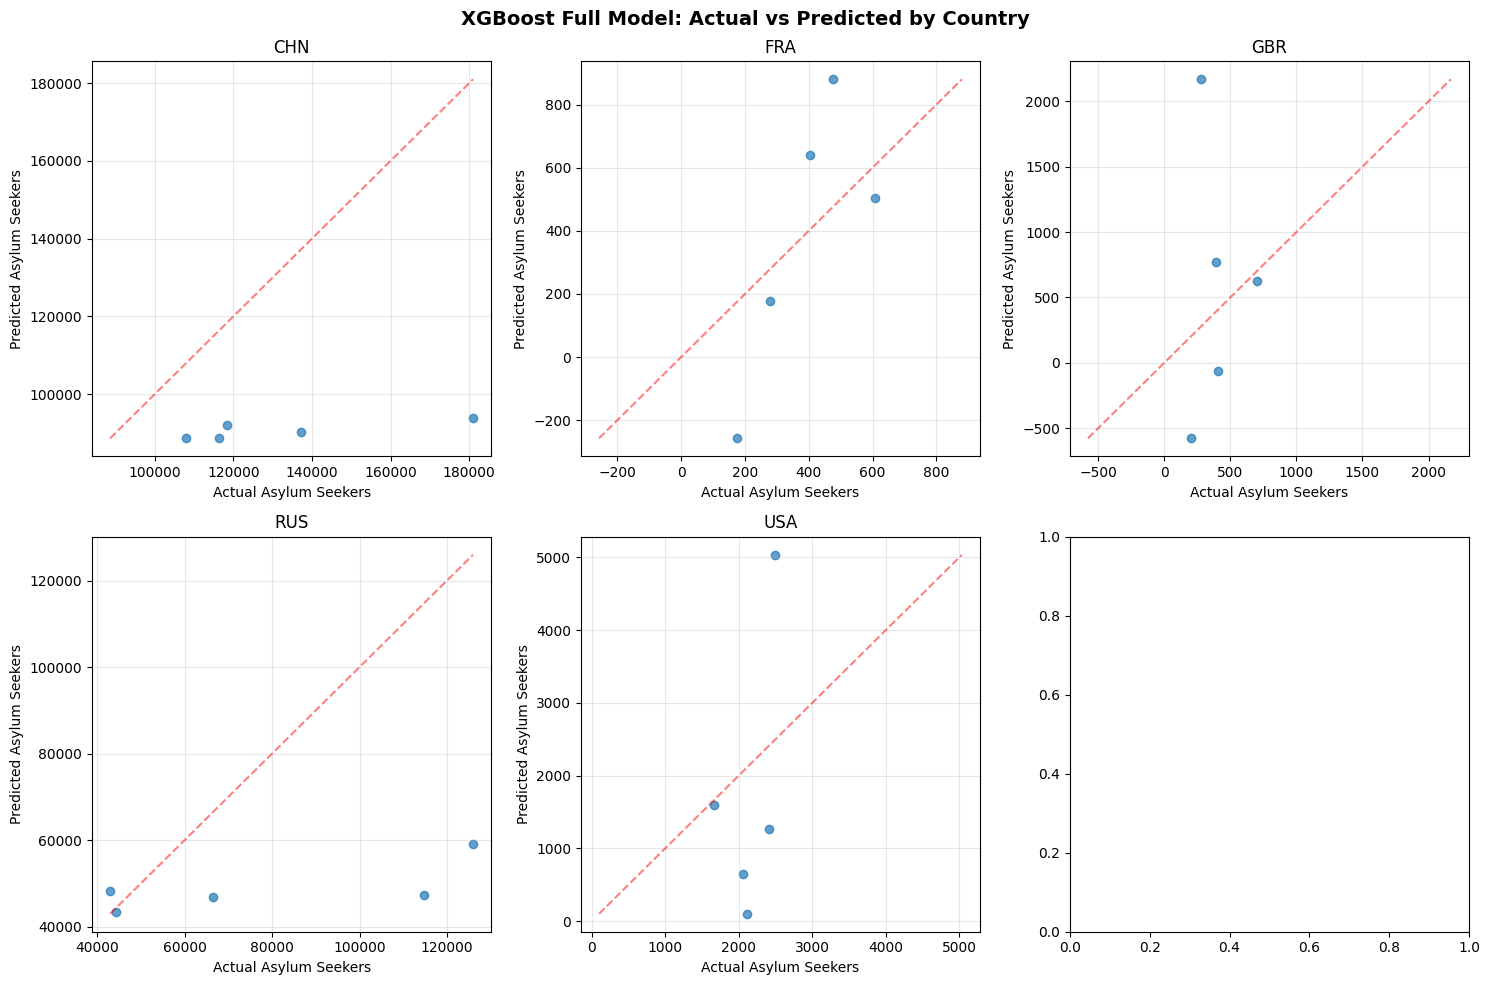

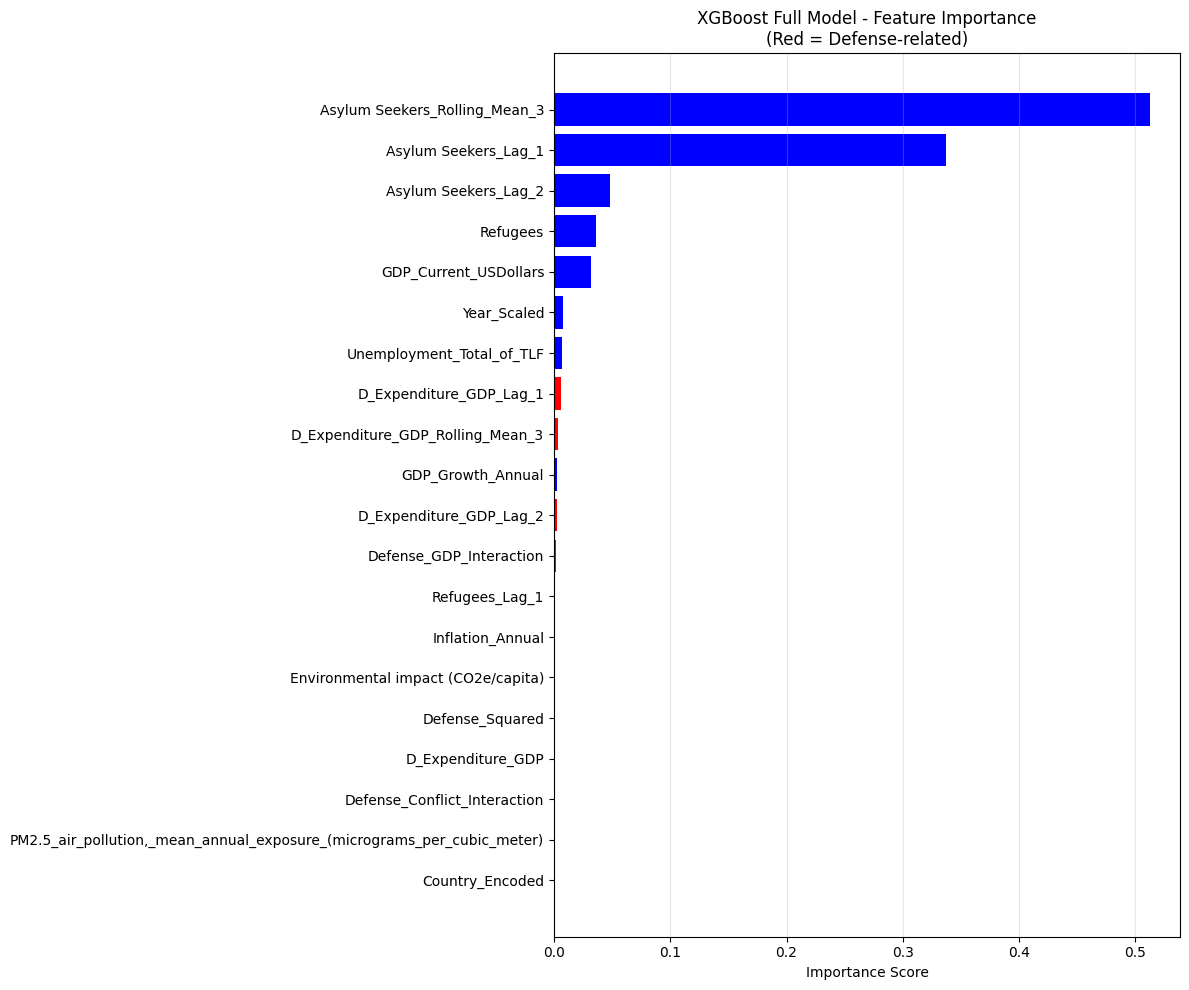


🔍 TOP 10 MOST IMPORTANT FEATURES:
  1. 📊 Asylum Seekers_Rolling_Mean_3: 0.5128
  2. 📊 Asylum Seekers_Lag_1: 0.3376
  3. 📊 Asylum Seekers_Lag_2: 0.0479
  4. 📊 Refugees: 0.0363
  5. 📊 GDP_Current_USDollars: 0.0316
  6. 📊 Year_Scaled: 0.0080
  7. 📊 Unemployment_Total_of_TLF: 0.0068
  8. 🛡️ D_Expenditure_GDP_Lag_1: 0.0062
  9. 🛡️ D_Expenditure_GDP_Rolling_Mean_3: 0.0033
  10. 📊 GDP_Growth_Annual: 0.0027

📝 EXAMPLE PREDICTIONS

🔮 MAKING PREDICTION:
  Country: FRA
  Year: 2025
  Defense GDP %: 2.0%

✅ PREDICTION RESULT:
  Predicted Asylum Seekers: 503

📊 Model Confidence:
  Defense-related features importance: 1.4%
  Historical patterns importance: 98.6%

🔮 MAKING PREDICTION:
  Country: FRA
  Year: 2025
  Defense GDP %: 3.5%

✅ PREDICTION RESULT:
  Predicted Asylum Seekers: 503

📊 Model Confidence:
  Defense-related features importance: 1.4%
  Historical patterns importance: 98.6%

🔮 MAKING PREDICTION:
  Country: GBR
  Year: 2025
  Defense GDP %: 2.2%

✅ PREDICTION RESULT:
  Predicted Asylu

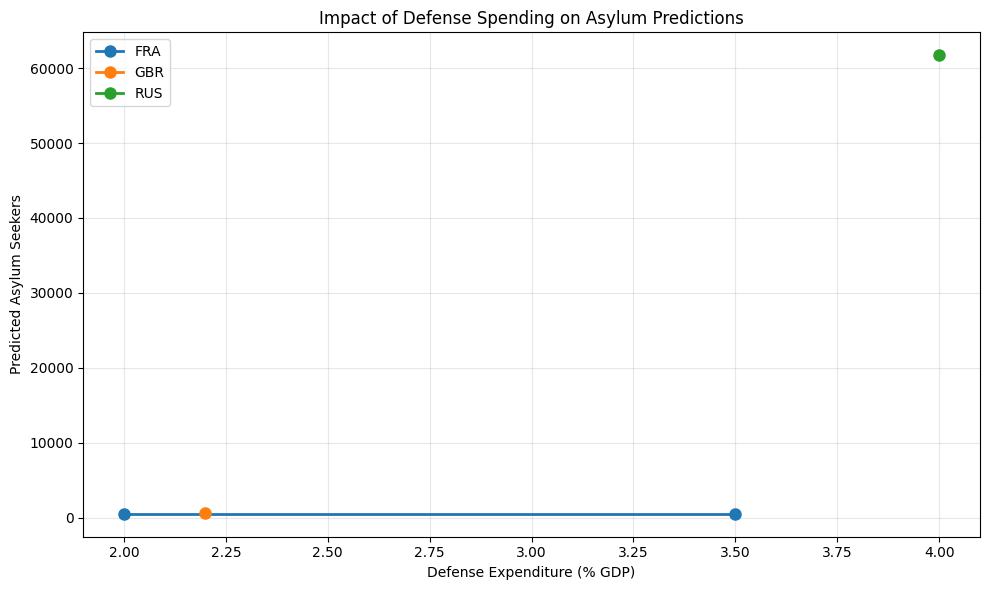


✅ ANALYSIS COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# ==========================
# DATA LOADING AND PREPROCESSING
# ==========================
def load_and_preprocess_data(file_path):
    """
    Load and preprocess the dataset
    """
    print("📁 LOADING DATASET...")
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace('\n', ' ')
    df.columns = df.columns.str.replace('  ', ' ')

    print(f"✅ Dataset loaded: {df.shape}")
    return df

def prepare_features(df, target_col='Asylum Seekers'):
    """
    Prepare features for XGBoost model
    """
    df_processed = df.copy()

    print("\n🔧 PREPARING FEATURES FOR XGBOOST...")

    # 1. Handle missing values
    print("   Handling missing values...")
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if col != target_col and col != 'Country' and col != 'Year':
            # Fill with median by country
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            # If still missing, fill with overall median
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # 2. Encode categorical variables
    print("   Encoding categorical variables...")
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

    # Store country mapping
    country_mapping = dict(zip(le_country.classes_, le_country.transform(le_country.classes_)))
    print(f"   Country mapping: {country_mapping}")

    # 3. Create time-based features
    print("   Creating time-based features...")
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # 4. Create lag features for key variables
    print("   Creating lag features...")
    key_vars = [
        'D_Expenditure_GDP',
        'Asylum Seekers',
        'GDP_Current_USDollars',
        'Population',
        'Refugees'
    ]

    existing_vars = [var for var in key_vars if var in df_processed.columns]

    for var in existing_vars:
        for lag in [1, 2, 3]:
            df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)

    # 5. Create rolling statistics
    print("   Creating rolling statistics...")
    for var in ['D_Expenditure_GDP', 'Asylum Seekers']:
        if var in df_processed.columns:
            df_processed[f'{var}_Rolling_Mean_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )

    # 6. Create interaction features
    print("   Creating interaction features...")
    if 'D_Expenditure_GDP' in df_processed.columns:
        if 'GDP_Current_USDollars' in df_processed.columns:
            df_processed['Defense_GDP_Interaction'] = df_processed['D_Expenditure_GDP'] * np.log1p(df_processed['GDP_Current_USDollars'])
        if 'Conflict_Intensity' in df_processed.columns:
            df_processed['Defense_Conflict_Interaction'] = df_processed['D_Expenditure_GDP'] * df_processed['Conflict_Intensity']
        df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP'] ** 2

    # 7. Fill remaining NaN values
    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill').fillna(0)

    print(f"✅ Final dataset shape: {df_processed.shape}")
    print(f"✅ Total features: {len(df_processed.columns)}")

    return df_processed, le_country

# ==========================
# XGBOOST FULL MODEL
# ==========================
class XGBoostFullModel:
    """
    XGBoost model with all features for asylum seeker prediction
    """
    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None

    def get_full_features(self, df):
        """
        Get all available features for the full model
        """
        base_features = [
            'Year_Scaled',
            'Country_Encoded',
            'D_Expenditure_GDP',
        ]

        defense_features = [
            'D_Expenditure_GDP_Lag_1',
            'D_Expenditure_GDP_Lag_2',
            'D_Expenditure_GDP_Rolling_Mean_3',
            'Defense_Squared',
        ]

        economic_features = [
            'GDP_Current_USDollars',
            'GDP_Growth_Annual',
            'Inflation_Annual',
            'Unemployment_Total_of_TLF',
        ]

        migration_features = [
            'Refugees',
            'Refugees_Lag_1',
            'Asylum Seekers_Lag_1',
            'Asylum Seekers_Lag_2',
            'Asylum Seekers_Rolling_Mean_3',
        ]

        # Add interaction features if they exist
        interaction_features = []
        if 'Defense_GDP_Interaction' in df.columns:
            interaction_features.append('Defense_GDP_Interaction')
        if 'Defense_Conflict_Interaction' in df.columns:
            interaction_features.append('Defense_Conflict_Interaction')

        # Combine all features
        all_features = (base_features + defense_features + economic_features +
                       migration_features + interaction_features)

        # Add environmental features if they exist
        env_cols = [col for col in df.columns if 'Environmental' in col or 'PM2.5' in col or 'CO2' in col]
        all_features.extend(env_cols)

        # Remove duplicates and filter to existing columns
        all_features = list(set(all_features))
        available_features = [f for f in all_features if f in df.columns]

        print(f"\n📋 FULL MODEL FEATURES ({len(available_features)} total):")
        for i, feature in enumerate(sorted(available_features)):
            print(f"  {i+1}. {feature}")

        return available_features

    def train(self, df, target_col='Asylum Seekers', test_years=[2020, 2021, 2022, 2023, 2024]):
        """
        Train XGBoost model on all features
        """
        print("\n" + "="*60)
        print("🚀 TRAINING XGBOOST FULL MODEL")
        print("="*60)

        # Get features
        self.feature_names = self.get_full_features(df)

        # Prepare data
        X = df[self.feature_names]
        y = df[target_col]

        # Split by time
        train_mask = ~df['Year'].isin(test_years)
        test_mask = df['Year'].isin(test_years)

        X_train = X[train_mask]
        X_test = X[test_mask]
        y_train = y[train_mask]
        y_test = y[test_mask]

        print(f"\n📊 Data Split:")
        print(f"  Training: {len(X_train)} samples ({df['Year'].min()} - {test_years[0]-1})")
        print(f"  Testing: {len(X_test)} samples ({test_years[0]} - {test_years[-1]})")

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Train XGBoost model
        print("\n🤖 Training XGBoost...")
        self.model = XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1
        )

        self.model.fit(X_train_scaled, y_train)
        print("✅ Training complete!")

        # Evaluate
        self.evaluate(X_test_scaled, y_test, df[test_mask]['Country'])

        # Feature importance
        self.plot_feature_importance()

        return self.model

    def evaluate(self, X_test, y_test, countries_test):
        """
        Evaluate model performance
        """
        print("\n" + "="*60)
        print("📊 MODEL EVALUATION")
        print("="*60)

        # Make predictions
        y_pred = self.model.predict(X_test)

        # Overall metrics
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = self.calculate_mape(y_test, y_pred)

        print(f"\n📈 Overall Performance:")
        print(f"  R² Score:  {r2:.4f} ({r2*100:.1f}% accuracy)")
        print(f"  MAE:       {mae:,.2f} people")
        print(f"  RMSE:      {rmse:,.2f} people")
        print(f"  MAPE:      {mape:.2f}%")

        # Country-wise performance
        print(f"\n🌍 Country-wise Performance:")
        print("-" * 60)

        test_data = pd.DataFrame({
            'Country': countries_test.values,
            'Actual': y_test.values,
            'Predicted': y_pred
        })

        country_results = []
        for country in test_data['Country'].unique():
            country_mask = test_data['Country'] == country
            country_actual = test_data.loc[country_mask, 'Actual']
            country_pred = test_data.loc[country_mask, 'Predicted']

            if len(country_actual) > 1:
                country_r2 = r2_score(country_actual, country_pred)
            else:
                country_r2 = np.nan

            country_mae = mean_absolute_error(country_actual, country_pred)
            country_mape = self.calculate_mape(country_actual, country_pred)

            country_results.append({
                'Country': country,
                'R2': country_r2,
                'MAE': country_mae,
                'MAPE': country_mape,
                'Samples': len(country_actual)
            })

        # Display country results
        country_df = pd.DataFrame(country_results)
        country_df = country_df.sort_values('R2', ascending=False)

        for _, row in country_df.iterrows():
            r2_display = f"{row['R2']:.4f}" if not np.isnan(row['R2']) else "N/A"
            print(f"  {row['Country']}:")
            print(f"    R² = {r2_display}")
            print(f"    MAE = {row['MAE']:,.0f}")
            print(f"    MAPE = {row['MAPE']:.1f}%")
            print()

        # Plot actual vs predicted
        self.plot_predictions(test_data)

        return country_df

    def calculate_mape(self, y_true, y_pred):
        """Calculate Mean Absolute Percentage Error"""
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        mask = y_true != 0
        if np.sum(mask) == 0:
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    def plot_feature_importance(self):
        """Plot feature importance"""
        importance = pd.DataFrame({
            'Feature': self.feature_names,
            'Importance': self.model.feature_importances_
        }).sort_values('Importance', ascending=True)

        plt.figure(figsize=(12, 10))
        colors = ['red' if 'Defense' in f or 'D_Expenditure' in f else 'blue'
                 for f in importance['Feature']]

        plt.barh(range(len(importance)), importance['Importance'], color=colors)
        plt.yticks(range(len(importance)), importance['Feature'])
        plt.xlabel('Importance Score')
        plt.title('XGBoost Full Model - Feature Importance\n(Red = Defense-related)')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

        # Print top features
        print("\n🔍 TOP 10 MOST IMPORTANT FEATURES:")
        top_features = importance.sort_values('Importance', ascending=False).head(10)
        for i, (_, row) in enumerate(top_features.iterrows(), 1):
            defense_tag = "🛡️" if 'Defense' in row['Feature'] or 'D_Expenditure' in row['Feature'] else "📊"
            print(f"  {i}. {defense_tag} {row['Feature']}: {row['Importance']:.4f}")

    def plot_predictions(self, test_data):
        """Plot actual vs predicted values by country"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()

        for idx, country in enumerate(test_data['Country'].unique()[:6]):
            if idx < len(axes):
                country_data = test_data[test_data['Country'] == country]

                ax = axes[idx]
                ax.scatter(country_data['Actual'], country_data['Predicted'], alpha=0.7)

                # Add perfect prediction line
                min_val = min(country_data['Actual'].min(), country_data['Predicted'].min())
                max_val = max(country_data['Actual'].max(), country_data['Predicted'].max())
                ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)

                ax.set_xlabel('Actual Asylum Seekers')
                ax.set_ylabel('Predicted Asylum Seekers')
                ax.set_title(f'{country}')
                ax.grid(True, alpha=0.3)

        plt.suptitle('XGBoost Full Model: Actual vs Predicted by Country', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def predict(self, country, year, defense_gdp, df_history):
        """
        Make prediction for a specific country and year with user input
        """
        print(f"\n🔮 MAKING PREDICTION:")
        print(f"  Country: {country}")
        print(f"  Year: {year}")
        print(f"  Defense GDP %: {defense_gdp}%")

        # Get historical data for this country
        country_history = df_history[df_history['Country'] == country].copy()

        if len(country_history) == 0:
            print(f"❌ No historical data for {country}")
            return None

        # Get the latest data
        latest = country_history.iloc[-1].copy()

        # Create prediction row
        pred_row = latest.copy()
        pred_row['Year'] = year
        pred_row['Year_Scaled'] = year - df_history['Year'].min()
        pred_row['D_Expenditure_GDP'] = defense_gdp

        # Update lag features
        if 'D_Expenditure_GDP_Lag_1' in self.feature_names:
            pred_row['D_Expenditure_GDP_Lag_1'] = latest['D_Expenditure_GDP']
        if 'D_Expenditure_GDP_Lag_2' in self.feature_names:
            pred_row['D_Expenditure_GDP_Lag_2'] = country_history['D_Expenditure_GDP'].iloc[-2] if len(country_history) > 1 else latest['D_Expenditure_GDP']

        # Update rolling mean
        if 'D_Expenditure_GDP_Rolling_Mean_3' in self.feature_names:
            last_3 = country_history['D_Expenditure_GDP'].tail(3).tolist()
            if len(last_3) < 3:
                last_3 = [defense_gdp] * 3
            pred_row['D_Expenditure_GDP_Rolling_Mean_3'] = np.mean(last_3)

        # Update asylum lags if they exist
        if 'Asylum Seekers_Lag_1' in self.feature_names:
            pred_row['Asylum Seekers_Lag_1'] = latest['Asylum Seekers']
        if 'Asylum Seekers_Lag_2' in self.feature_names and len(country_history) > 1:
            pred_row['Asylum Seekers_Lag_2'] = country_history['Asylum Seekers'].iloc[-2]

        # Prepare features
        X_pred = pd.DataFrame([pred_row[self.feature_names]])

        # Handle any missing values
        X_pred = X_pred.fillna(0)

        # Scale
        X_pred_scaled = self.scaler.transform(X_pred)

        # Predict
        prediction = self.model.predict(X_pred_scaled)[0]

        print(f"\n✅ PREDICTION RESULT:")
        print(f"  Predicted Asylum Seekers: {prediction:,.0f}")

        # Show confidence
        if hasattr(self.model, 'feature_importances_'):
            defense_importance = sum(self.model.feature_importances_[
                [i for i, f in enumerate(self.feature_names)
                 if 'Defense' in f or 'D_Expenditure' in f]
            ])
            print(f"\n📊 Model Confidence:")
            print(f"  Defense-related features importance: {defense_importance:.1%}")
            print(f"  Historical patterns importance: {1-defense_importance:.1%}")

        return prediction

# ==========================
# MAIN EXECUTION
# ==========================
def main():
    print("="*60)
    print("🎯 XGBOOST FULL MODEL FOR ASYLUM SEEKER PREDICTION")
    print("="*60)

    # Load data
    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'
    df = load_and_preprocess_data(file_path)

    # Prepare features
    df_processed, le_country = prepare_features(df)

    # Create and train XGBoost model
    xgb_model = XGBoostFullModel()
    xgb_model.train(df_processed)

    # Example predictions
    print("\n" + "="*60)
    print("📝 EXAMPLE PREDICTIONS")
    print("="*60)

    # Test different scenarios
    test_scenarios = [
        ('FRA', 2025, 2.0),  # France with 2% defense
        ('FRA', 2025, 3.5),  # France with 3.5% defense
        ('GBR', 2025, 2.2),  # UK with 2.2% defense
        ('RUS', 2025, 4.0),  # Russia with 4% defense
    ]

    results = []
    for country, year, defense_gdp in test_scenarios:
        pred = xgb_model.predict(country, year, defense_gdp, df_processed)
        if pred:
            results.append({
                'Country': country,
                'Year': year,
                'Defense_GDP': defense_gdp,
                'Predicted_Asylum': pred
            })

    # Compare predictions
    if results:
        results_df = pd.DataFrame(results)
        print("\n📊 PREDICTION COMPARISON:")
        print(results_df.to_string(index=False))

        # Plot comparison
        plt.figure(figsize=(10, 6))
        for country in results_df['Country'].unique():
            country_results = results_df[results_df['Country'] == country]
            plt.plot(country_results['Defense_GDP'], country_results['Predicted_Asylum'],
                    'o-', label=country, linewidth=2, markersize=8)

        plt.xlabel('Defense Expenditure (% GDP)')
        plt.ylabel('Predicted Asylum Seekers')
        plt.title('Impact of Defense Spending on Asylum Predictions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    print("\n" + "="*60)
    print("✅ ANALYSIS COMPLETE!")
    print("="*60)

    return xgb_model, results_df

# Run the model
if __name__ == "__main__":
    xgb_model, results = main()